In [63]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import scipy.stats as stats


## Data processing

In [64]:
# download orginal dataset
df=pd.read_csv("case1Data.csv")

# create vector for target variable (y)
y_class=df["y"]

# create dataframe for features, numerical and categorical (x)
data=df.drop("y",axis=1)

# only categorical features
categorical_data=data[["C_01", "C_02", "C_03", "C_04", "C_05"]]

# only numeric features
numerical_data=data.drop(columns=categorical_data.columns)

numerical_data = numerical_data.fillna(numerical_data.median(numeric_only=True))
print(numerical_data.isna().sum())

categorical_data.drop(columns="C_02", inplace=True)

categorical_data = categorical_data.fillna("missing")
print(categorical_data.isna().sum())

categorical_data = pd.get_dummies(categorical_data)
categorical_data = categorical_data.astype(int)
categorical_data.head()

categorical_data.columns = categorical_data.columns.str.replace(".0", "", regex=False)
categorical_data.head()

X = pd.concat([numerical_data, categorical_data], axis=1)
print(X.shape)
X.head()

x_01    0
x_02    0
x_03    0
x_04    0
x_05    0
       ..
x_91    0
x_92    0
x_93    0
x_94    0
x_95    0
Length: 95, dtype: int64
C_01    0
C_03    0
C_04    0
C_05    0
dtype: int64
(100, 119)


,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,x_10,...,C_04_73,C_04_74,C_04_75,C_04_missing,C_05_71,C_05_72,C_05_73,C_05_74,C_05_75,C_05_missing
0,6.359019,-13.367120,-2.483750,-6.641891,11.733539,-3.771067,-17.085361,22.194764,16.827888,-10.367142,...,1,0,0,0,0,0,1,0,0,0
1,3.873664,-8.470389,-3.055012,-5.793856,11.420983,1.822330,-13.694100,22.738654,20.307503,-2.859097,...,1,0,0,0,0,0,1,0,0,0
2,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,22.435510,15.963889,-3.257940,...,0,1,0,0,0,0,0,1,0,0
3,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,-5.616061,...,0,0,0,0,0,1,0,0,0,0
4,3.116458,-8.518713,-6.796050,-5.793856,7.646285,-3.118309,-13.102567,22.801217,16.680208,-3.357765,...,0,1,0,0,0,0,0,0,1,0


## 1. Nested Cross Validation for RMSE

In [14]:
X_np = X.values
y_np = y_class.values

outer_folds = 5
n_repeats = 10

# for the repetitions of the outer cv
repetitions_rmse = []
best_params = []
# residual analysis
y_cv_true = []
y_cv_pred = []

# parameters to try
param_grid = {
    'n_estimators': [100, 300, 500],
    'estimator__max_depth': [10, 20],
    'estimator__min_samples_leaf': [3,5],
}


for repeat in range(n_repeats):
    outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=42 + repeat)  # change seed each repeat
    
    # an error value per outer test fold (5 test folds)
    rmse_per_fold = []

    # outer cv for model evaluation
    for train_out_idx, test_out_idx in outer_cv.split(X_np):

        X_train = X_np[train_out_idx].copy()
        y_train = y_np[train_out_idx]
        X_test = X_np[test_out_idx].copy()
        y_test = y_np[test_out_idx]

        seed = 42 + repeat

        base_tree = DecisionTreeRegressor(
            criterion='squared_error',
            splitter='best',
            max_features=None,
            random_state=seed
        )
        
        bagging = BaggingRegressor(
            estimator=base_tree,
            bootstrap=True,
            random_state=seed,
            n_jobs=-1
        )

        #inner cv for model selection
        grid = GridSearchCV(
            estimator=bagging,
            param_grid=param_grid,
            cv=5,  
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        best_param = grid.best_params_
        best_params.append(best_param)

        # evaluate on outer test fold
        y_pred = best_model.predict(X_test)
        fold_rmse = np.sqrt(np.mean((y_pred - y_test)**2))
        rmse_per_fold.append(fold_rmse)
        y_cv_true.extend(y_test) 
        y_cv_pred.extend(y_pred)

    repetitions_rmse.extend(rmse_per_fold)

nested_cv_rmse = np.mean(repetitions_rmse)
nested_cv_std = np.std(repetitions_rmse) / np.sqrt(len(repetitions_rmse))
print(f"Repeated Nested CV estimated RMSE: {nested_cv_rmse:.4f} ± {nested_cv_std:.4f}")

Repeated Nested CV estimated RMSE: 46.3698 ± 1.0516


## 2. Residuals

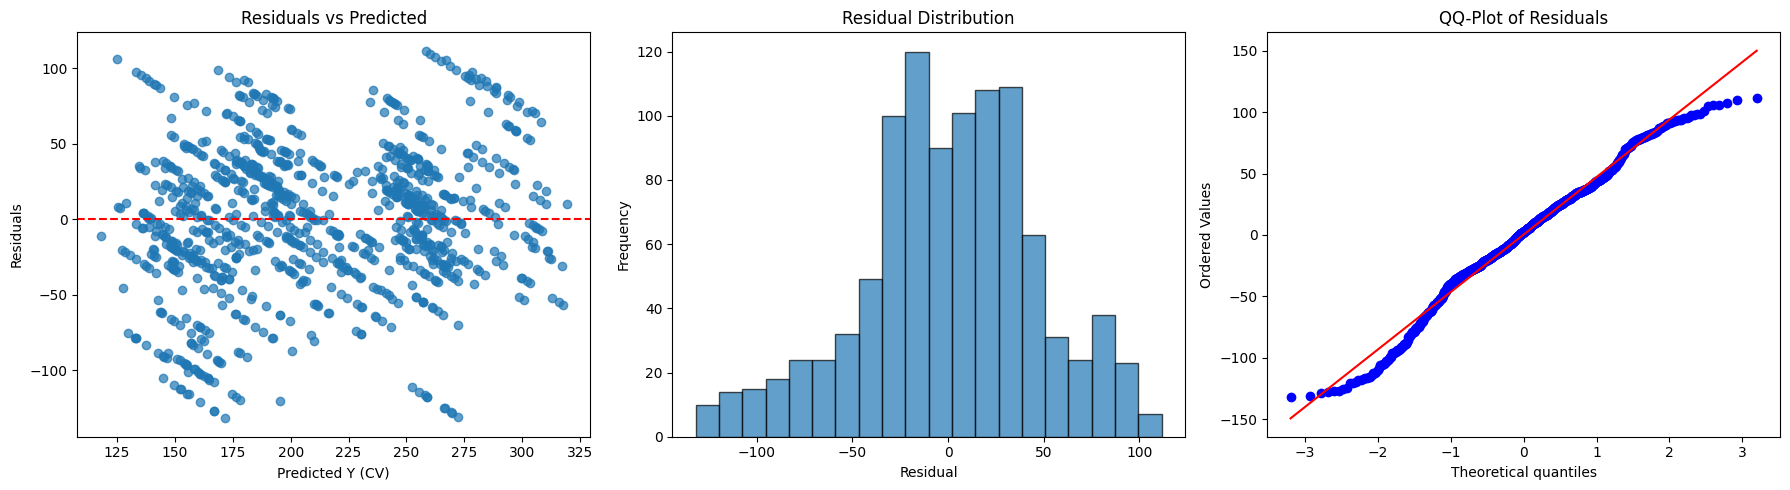

In [17]:
y_cv_true = np.array(y_cv_true)
y_cv_pred = np.array(y_cv_pred)

residuals = y_cv_true - y_cv_pred

fig, axes = plt.subplots(1, 3, figsize=(18,5))  

axes[0].scatter(y_cv_pred, residuals, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted Y (CV)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("QQ-Plot of Residuals")
plt.tight_layout()  
plt.show()

## 3. Final model with CV

In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error

# criterion is squared error
# splitter as best since features are not super correlated
# use all features in every split
base_tree = DecisionTreeRegressor(criterion='squared_error', splitter="best", max_features=None, random_state=42)

# define bagging ensemble
# each tree is trained on a bootstrap sample 
# 37% of obs are left out on each tree and used to compute oob
bagging = BaggingRegressor(
    estimator=base_tree,  
    oob_score=True,
    bootstrap=True,
    random_state=42
)

# enough trees to stabilize 
# maybe too deep trees and then overfitting
# large leafs so it doesnt represent noise
param_grid = {
    'n_estimators': [100, 300, 500],
    'estimator__max_depth': [10, 20],
    'estimator__min_samples_leaf': [3,5],
}

#Try all parameter combos. For each combo, do k-fold CV and compute average RMSE. Pick the best combo.”
grid = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='neg_root_mean_squared_error'
)

grid.fit(X, y_class)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'estimator__max_depth': 20, 'estimator__min_samples_leaf': 3, 'n_estimators': 500}
Best CV accuracy: -47.130750328721


## Random Forest

- explain grid parameters
- seed in RF
- different criterion
- oob add ?

- graficos cada variavel vs mse
- outros graficos dos exs
- 2 std

In [65]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
import numpy as np

X_np = X.values
y_np = y_class.values

n_repeats = 10
outer_folds = 5

#each row corresponds to each repetition rmse (5 values, 1 per fold)
repetitions_rmse = []
#feature importance per repetition
repetitions_fimp = []
best_params = []

#to check residuals after
y_cv_true = []
y_cv_pred = []

p = len(numerical_data)
m = p//3

param_grid = {
    'n_estimators': [100, 300, 500], #big number so we can reduce variance
    'max_depth': [3, 5, 10], #shallow trees so it doesnt overfit
    'min_samples_leaf': [5, 10], #not very small to prevent the tree from learning noise
    'max_features': ['sqrt', 'log2', m] #to decorrelate the trees 
}


#change composition of folds
for repeat in range(n_repeats):
    outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=42 + repeat)

    #saves 5 values per repetition, since we have 5 test sets
    folds_rmse = []
    folds_fimp = []

    #split data in 5 folds, 1 for test and 4 for hyperparameter tuning
    for train_out_idx, test_out_idx in outer_cv.split(X_np):

        X_train = X_np[train_out_idx].copy()
        y_train = y_np[train_out_idx]
        X_test = X_np[test_out_idx].copy()
        y_test = y_np[test_out_idx]

        #trees minimize squared error when choosing were to split
        rf = RandomForestRegressor(
            criterion='squared_error',
            bootstrap=True,
            n_jobs=-1
        )

        #evaluates it with negative rmse
        grid = GridSearchCV(
            estimator=rf,
            param_grid=param_grid,
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        #save best parameters
        best_model = grid.best_estimator_
        best_params.append(grid.best_params_)

        #save best models feature importance
        folds_fimp.append(best_model.feature_importances_)

        #predict on test set
        y_pred = best_model.predict(X_test)
        fold_rmse = np.sqrt(np.mean((y_pred - y_test)**2))
        folds_rmse.append(fold_rmse)

        y_cv_true.extend(y_test)
        y_cv_pred.extend(y_pred)

    repetitions_rmse.extend(folds_rmse)
    repetitions_fimp.append(folds_fimp)

nested_cv_rmse = np.mean(repetitions_rmse)
nested_cv_std = np.std(repetitions_rmse) / np.sqrt(len(repetitions_rmse))
overall_std = np.std(repetitions_rmse)

print(f"Repeated Nested CV estimated RMSE: {nested_cv_rmse:.4f} ± {nested_cv_std:.4f}")
print(f"Overall std: {overall_std:.4f}")

Repeated Nested CV estimated RMSE: 55.5700 ± 1.4169
Overall std: 10.0192


Frequency of hyperparameters - to compare to final model

In [66]:
df_params = pd.DataFrame(best_params)
for col in df_params.columns:
    print(df_params[col].value_counts())
    print("\n")

max_depth
10    25
5     23
3      2
Name: count, dtype: int64


max_features
33    50
Name: count, dtype: int64


min_samples_leaf
5    50
Name: count, dtype: int64


n_estimators
100    19
500    17
300    14
Name: count, dtype: int64




Frequency of features - compare models

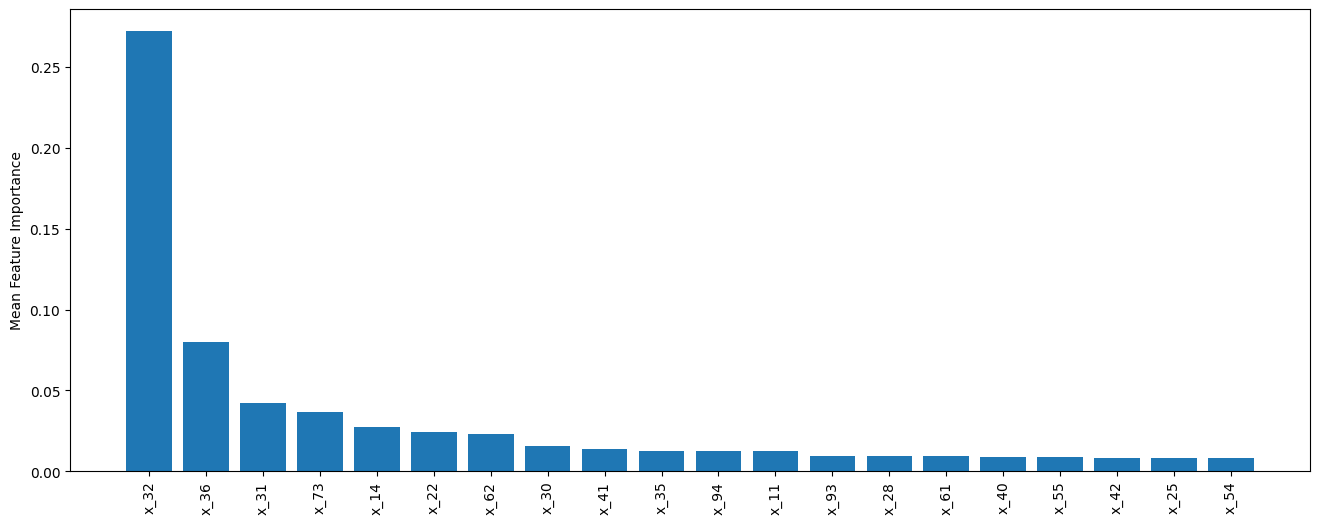

In [67]:
fimp = np.array(repetitions_fimp)         
fimp = fimp.reshape(-1, fimp.shape[2])  
fimp_df = pd.DataFrame(fimp, columns=X.columns)

mean_importance = fimp_df.mean(axis=0)
sorted_importance = mean_importance.sort_values(ascending=False)

plt.figure(figsize=(16, 6))
plt.bar(sorted_importance.index[:20], sorted_importance.values[:20])
plt.xticks(rotation=90)
plt.ylabel("Mean Feature Importance")
plt.show()

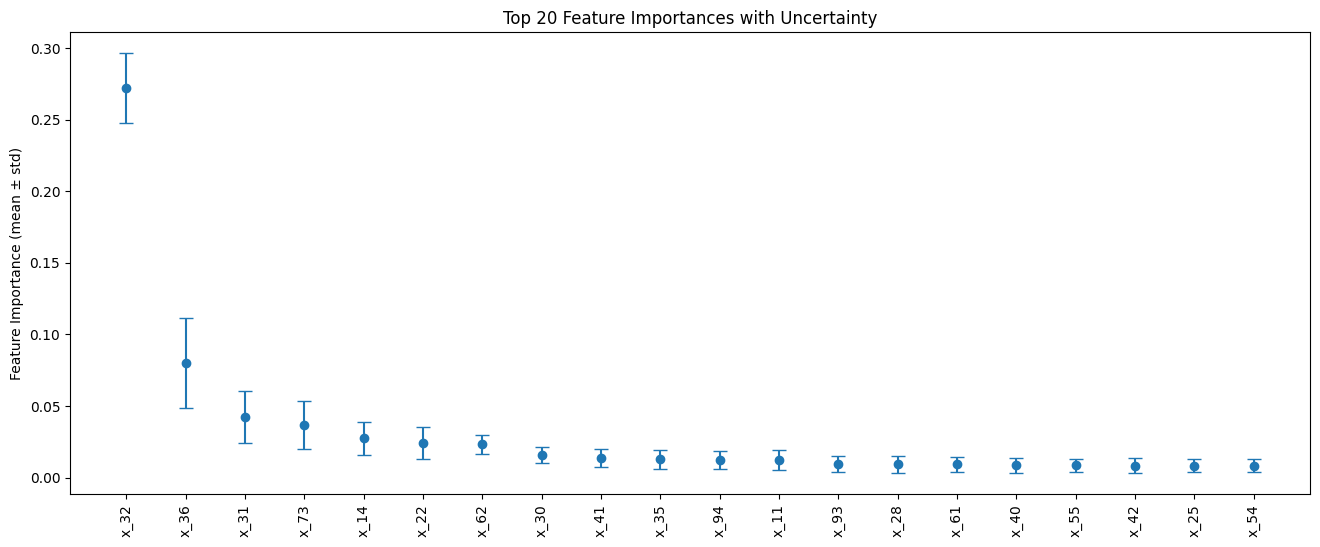

In [68]:
std_importance = fimp_df.std(axis=0)
top_features = sorted_importance.index[:20]
x = np.arange(len(top_features))

plt.figure(figsize=(16, 6))
plt.errorbar(x, mean_importance[top_features], yerr=std_importance[top_features],fmt='o',capsize=5)
plt.xticks(x, top_features, rotation=90)
plt.ylabel("Feature Importance (mean ± std)")
plt.title("Top 20 Feature Importances with Uncertainty")
plt.show()

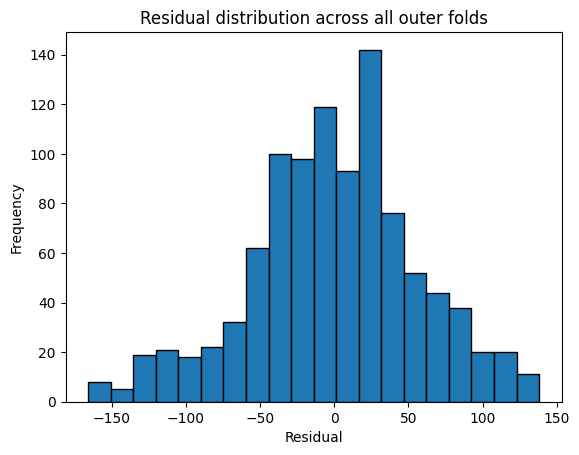

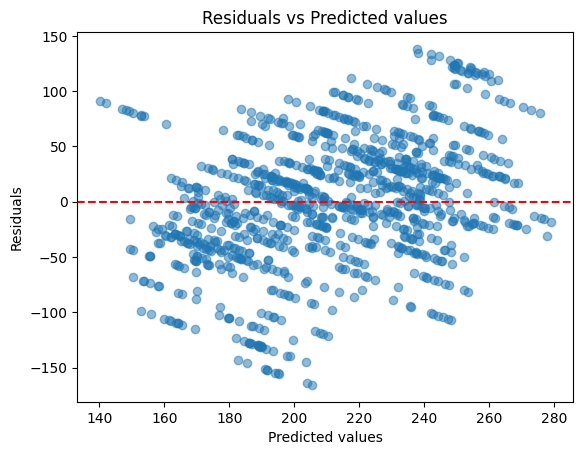

In [69]:
residuals = np.array(y_cv_true) - np.array(y_cv_pred)

plt.hist(residuals, bins=20, edgecolor='k')
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual distribution across all outer folds")
plt.show()

plt.scatter(y_cv_pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted values")
plt.show()

## 3. CV model sleecteion

In [70]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300, 500], #60 #big number so we can reduce var
    'max_depth': [3, 5, 10], #shallow trees so it doesnt overfit
    'min_samples_leaf': [5, 10], #also to prevent the tree learnign noise
    'max_features': ['sqrt', 'log2', m] #to decorrelate the trees 
}

rf = RandomForestRegressor(
    criterion='squared_error',
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,  
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_np, y_np)
final_model = grid.best_estimator_
print("Best parameters:", grid.best_params_)

Best parameters: {'max_depth': 10, 'max_features': 33, 'min_samples_leaf': 5, 'n_estimators': 500}


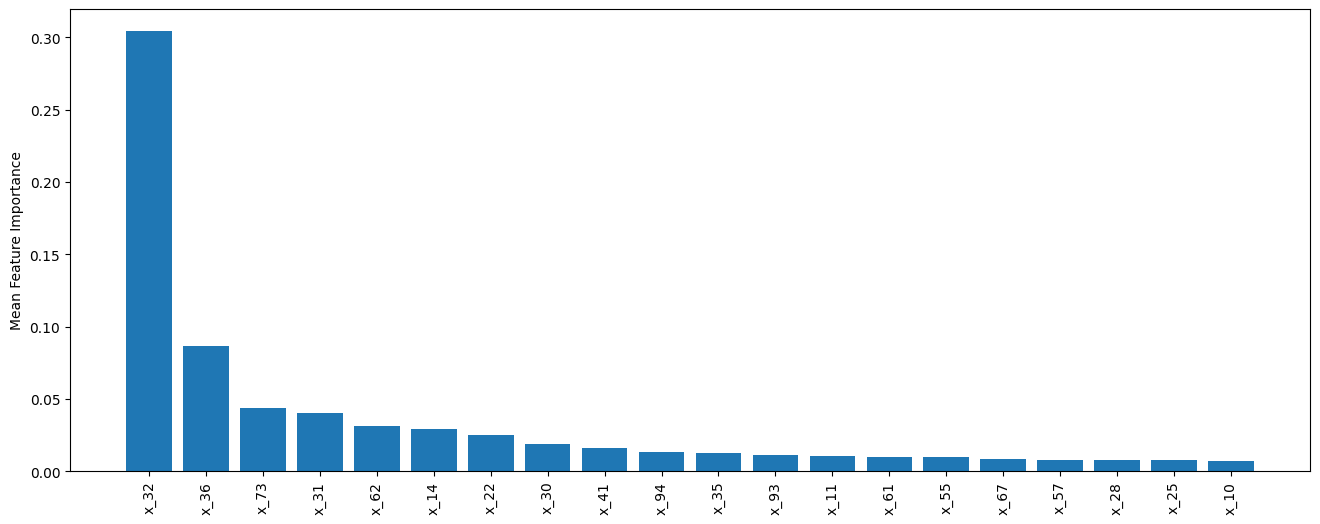

In [71]:
final_fimp = final_model.feature_importances_
final_fimp_df = pd.Series(final_fimp, index=X.columns)
final_fimp_sorted = final_fimp_df.sort_values(ascending=False)

plt.figure(figsize=(16, 6))
plt.bar(final_fimp_sorted.index[:20], final_fimp_sorted.values[:20])
plt.xticks(rotation=90)
plt.ylabel("Mean Feature Importance")
plt.show()

In [72]:
y_train_pred = final_model.predict(X_np)
train_rmse = np.sqrt(np.mean((y_np - y_train_pred)**2))
print("Training RMSE:", train_rmse)

Training RMSE: 32.436717222871756


Another try

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

outer_folds = 5
n_repeats = 10

outer_errors = []

param_grid = {
    'n_estimators': [100, 300, 500],
    'estimator__max_depth': [10, 20],
    'estimator__min_samples_leaf': [3, 5],
}

for repeat in range(n_repeats):
    outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=42 + repeat)
    
    for train_idx, test_idx in outer_cv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_class.iloc[train_idx], y_class.iloc[test_idx]

        # Base tree
        base_tree = DecisionTreeRegressor(
            criterion='squared_error',
            splitter='best',
            max_features=None,
            random_state=42
        )
        
        # Bagging ensemble
        bagging = BaggingRegressor(
            estimator=base_tree,
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        )

        # Inner CV for hyperparameter tuning
        grid = GridSearchCV(
            estimator=bagging,
            param_grid=param_grid,
            cv=5,  # inner CV
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_

        # Evaluate on outer test fold
        y_pred = best_model.predict(X_test)
        fold_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        outer_errors.append(fold_rmse)

# Aggregate over repeats
mean_rmse = np.mean(outer_errors)
std_rmse = np.std(outer_errors) / np.sqrt(len(outer_errors))
print(f"Repeated Nested CV estimated RMSE for Bagging: {mean_rmse:.4f} ± {std_rmse:.4f}")

Simple try

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error

# criterion is squared error
# splitter as best since features are not super correlated
# use all features in every split
base_tree = DecisionTreeRegressor(criterion='squared_error', splitter="best", max_features=None, random_state=42)


# define bagging ensemble
# each tree is trained on a bootstrap sample 
# 37% of obs are left out on each tree and used to compute oob
bagging = BaggingRegressor(
    estimator=base_tree,  
    oob_score=True,
    bootstrap=True,
    random_state=42
)

# enough trees to stabilize 
# maybe too deep trees and then overfitting
# large leafs so it doesnt represent noise
param_grid = {
    'n_estimators': [100, 300, 500],
    'estimator__max_depth': [8, 10, 12, 20],
    'estimator__min_samples_leaf': [3, 5],
}

#Try all parameter combos. For each combo, do k-fold CV and compute average RMSE. Pick the best combo.”
grid = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='neg_root_mean_squared_error'
)

grid.fit(X, y_class)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)